In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df_capped120_q1   = pd.read_csv("../tables/pubmed_central_20260309_183439.tsv", sep="\t")
df_capped200_q1   = pd.read_csv("../tables/pubmed_central_20260309_184017.tsv", sep="\t")
df_uncapped_q1 = pd.read_csv("../tables/pubmed_central_20260309_182908.tsv", sep="\t")
df_capped120_q2   = pd.read_csv("../tables/pubmed_central_20260309_180315.tsv", sep="\t")
df_capped200_q2   = pd.read_csv("../tables/pubmed_central_20260309_185606.tsv", sep="\t")
df_uncapped_q2 = pd.read_csv("../tables/pubmed_central_20260309_181417.tsv", sep="\t")

In [11]:
import sys, os, textwrap
sys.path.insert(0, "../scrapers")
from scrape_publications import build_search_query, build_search_query_v2

datasets = {
    "Q1 Capped 120": df_capped120_q1,
    "Q1 Capped 200": df_capped200_q1,
    "Q1 Uncapped":   df_uncapped_q1,
    "Q2 Capped 120": df_capped120_q2,
    "Q2 Capped 200": df_capped200_q2,
    "Q2 Uncapped":   df_uncapped_q2,
}

# ── Metrics ───────────────────────────────────────────────────────────────────
metrics = {}
for label, df in datasets.items():
    counts = df["Abbreviation"].value_counts()
    metrics[label] = {
        "Total records":          len(df),
        "Unique studies w/ hits": len(counts),
        "Max per study":          int(counts.max()),
        "Median per study":       round(float(counts.median()), 1),
        "top10":                  [f"{s} ({c})" for s, c in counts.head(10).items()],
    }

# ── Query examples ────────────────────────────────────────────────────────────
sample = df_capped120_q1.iloc[0]
q1_example = build_search_query(
    sample["Study Name"], sample["Abbreviation"],
    sample.get("Diseases Included", ""), sample.get("Coarse Data Modality", ""))
q2_example = build_search_query_v2(
    sample["Study Name"], sample["Abbreviation"],
    sample.get("Diseases Included", ""), sample.get("Coarse Data Modality", ""))

# ── Layout constants ──────────────────────────────────────────────────────────
col_w  = 22
lbl_w  = 30
labels = list(metrics.keys())
q1_labels = [l for l in labels if l.startswith("Q1")]
q2_labels = [l for l in labels if l.startswith("Q2")]
q1_span = len(q1_labels) * (col_w + 2)
q2_span = len(q2_labels) * (col_w + 2)
total_w = lbl_w + q1_span + q2_span

def hline(): print("-" * total_w)

def span_row(label, q1_text, q2_text):
    """Print a row with text wrapping within each group's span."""
    q1_lines = textwrap.wrap(q1_text, width=q1_span - 1) or [""]
    q2_lines = textwrap.wrap(q2_text, width=q2_span - 1) or [""]
    for i in range(max(len(q1_lines), len(q2_lines))):
        lbl    = label if i == 0 else ""
        q1_str = (q1_lines[i] if i < len(q1_lines) else "").ljust(q1_span)
        q2_str = (q2_lines[i] if i < len(q2_lines) else "").ljust(q2_span)
        print(f"{lbl:<{lbl_w}}{q1_str}{q2_str}")

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'':>{lbl_w}}{'── Q1 ──':^{q1_span}}{'── Q2 ──':^{q2_span}}")
print(f"{'Metric':<{lbl_w}}" + "".join(f"  {l:>{col_w}}" for l in labels))
hline()

span_row("Query type",
         "All Fields + disease terms + modality terms",
         "tiab only — no disease/modality, skips noisy abbrevs")
span_row("Query example", q1_example, q2_example)
hline()

for k in ["Total records", "Unique studies w/ hits", "Max per study", "Median per study"]:
    print(f"{k:<{lbl_w}}" + "".join(f"  {str(metrics[l][k]):>{col_w}}" for l in labels))

print(f"\nTop 10 studies")
for i in range(10):
    print(f"  #{i+1:<{lbl_w - 3}}" + "".join(
        f"  {(metrics[l]['top10'][i] if i < len(metrics[l]['top10']) else ''):>{col_w}}"
        for l in labels))

                                                              ── Q1 ──                                                                ── Q2 ──                                
Metric                                   Q1 Capped 120           Q1 Capped 200             Q1 Uncapped           Q2 Capped 120           Q2 Capped 200             Q2 Uncapped
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Query type                    All Fields + disease terms + modality terms                             tiab only — no disease/modality, skips noisy abbrevs                    
Query example                 ("Dominantly Inherited Alzheimer Network"[All Fields] OR "DIAN"[All     ("Dominantly Inherited Alzheimer Network"[tiab] OR "DIAN"[tiab]) AND    
                              Fields]) AND ("familial alzheimer's disease"[All Fields]) AND           (2023/03/10:2026/03/09[

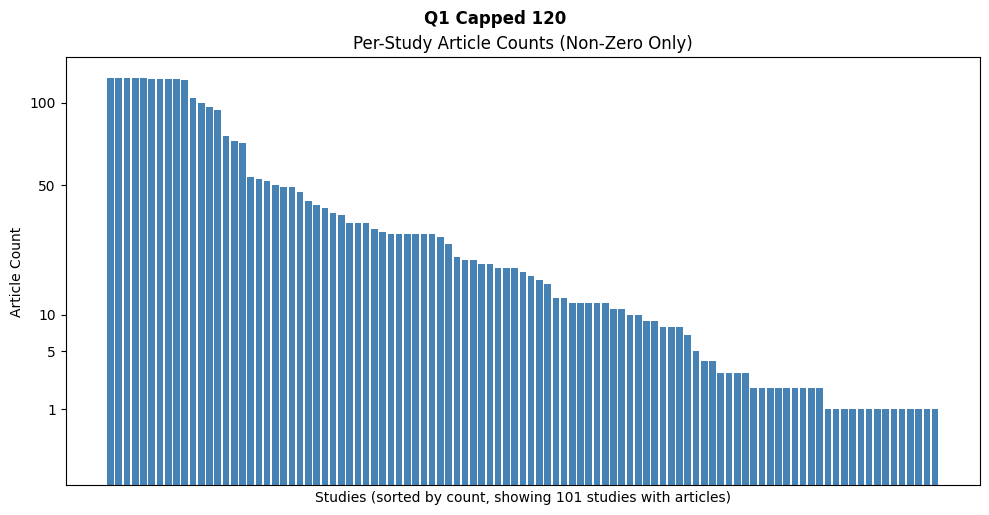

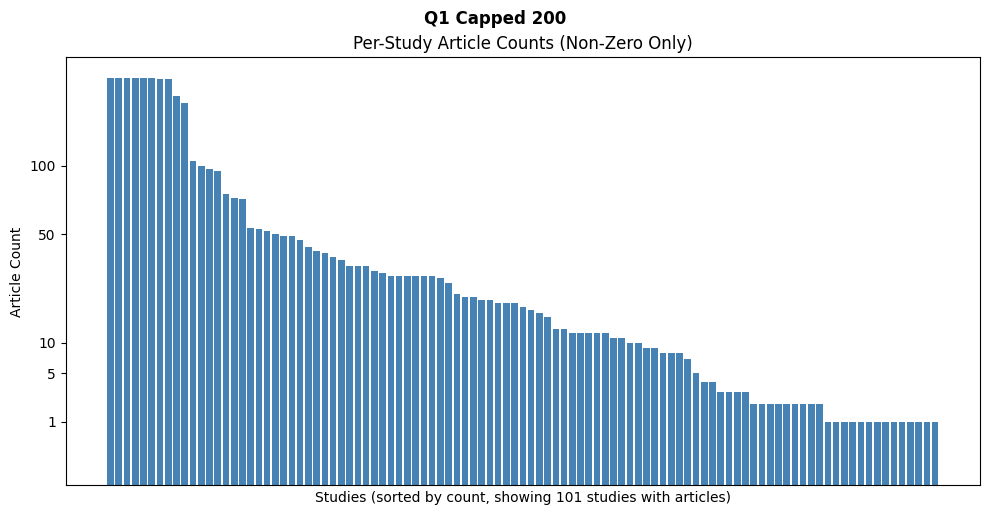

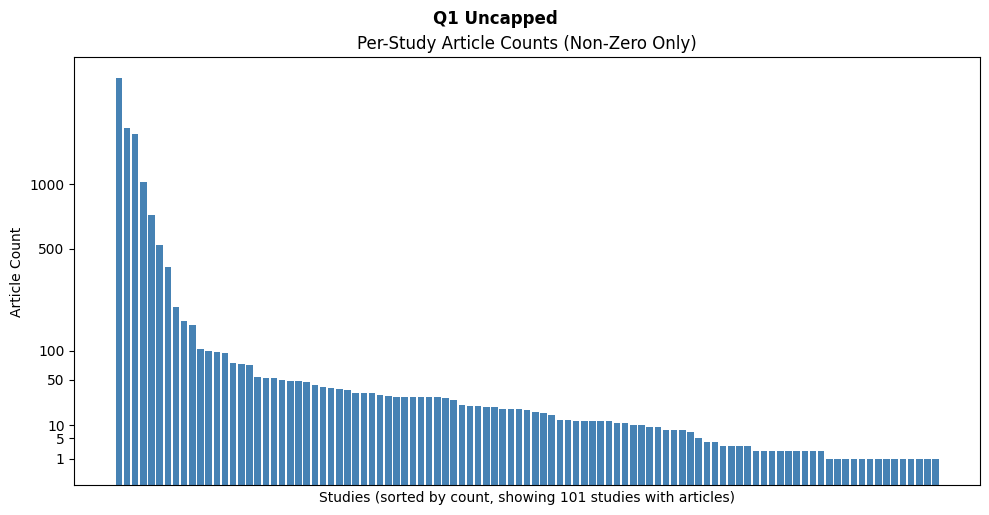

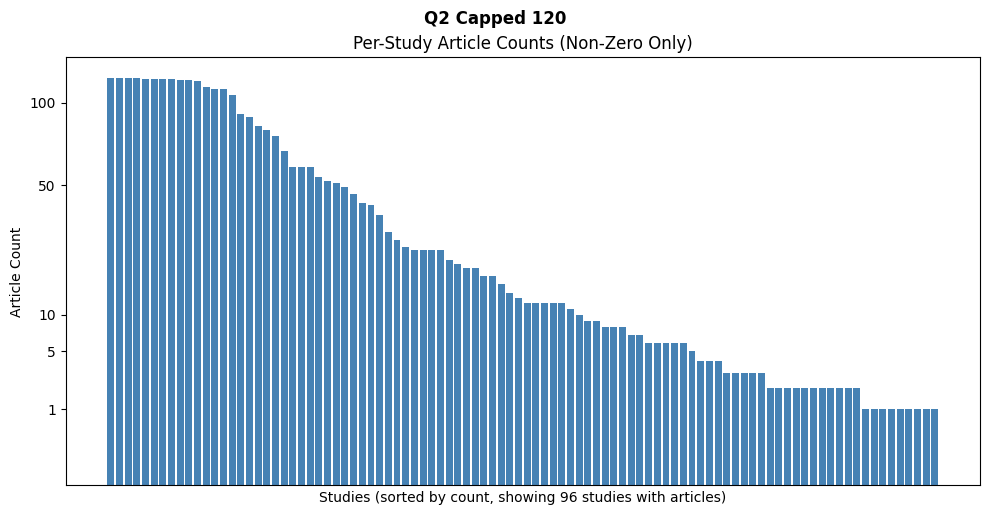

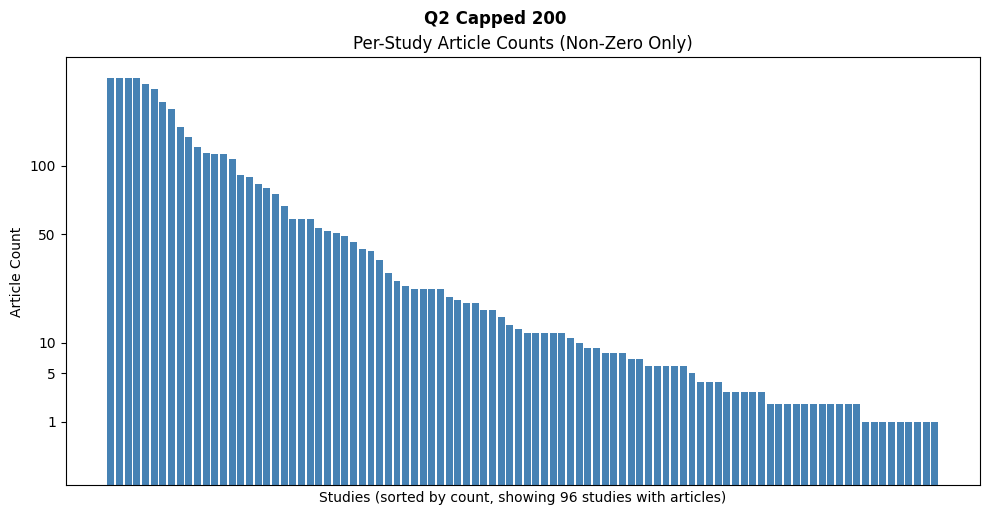

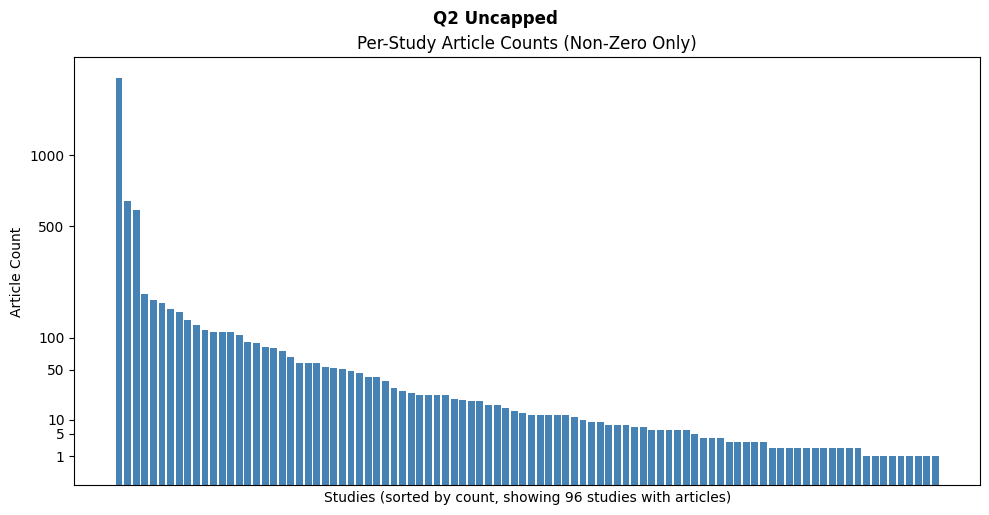

In [12]:
import matplotlib.ticker as ticker
import numpy as np

exp = 0.35  # tune: 1.0=linear, 0.5=sqrt, 0.3=more compressed

def plot_per_study_counts(df, label):
    counts = df["Study Name"].value_counts().sort_values(ascending=False)
    counts = counts[counts > 0]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(range(len(counts)), counts.values, color="steelblue", edgecolor="none")
    ax.set_yscale("function", functions=(
        lambda x: np.power(np.maximum(x, 0), exp),
        lambda x: np.power(np.maximum(x, 0), 1 / exp),
    ))
    ax.set_xlabel(f"Studies (sorted by count, showing {len(counts)} studies with articles)")
    ax.set_ylabel("Article Count")
    ax.set_title("Per-Study Article Counts (Non-Zero Only)")
    ax.set_xticks([])

    # Tick labels at round values
    max_val = int(counts.max())
    ticks = [t for t in [1, 5, 10, 50, 100, 500, 1000, 5000, 10000] if t <= max_val]
    ax.set_yticks(ticks)
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

    plt.tight_layout()
    plt.suptitle(label, y=1.02, fontsize=12, fontweight="bold")
    plt.show()

for label, df in datasets.items():
    plot_per_study_counts(df, label)